# Importing libraries

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_score

# Loading dataset

In [3]:
df = pd.read_csv('data/Titanic-Dataset.csv')

# Data understading

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
dtypes: float64(2), int64(5)
memory usage: 48.9 KB


In [10]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,1,22.0,1,0,7.2500
1,1,1,0,38.0,1,0,71.2833
2,1,3,0,26.0,0,0,7.9250
3,1,1,0,35.0,1,0,53.1000
4,0,3,1,35.0,0,0,8.0500


# Data preprocessing

## Data cleaning

In [6]:
df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin", "Embarked"], inplace=True)

In [7]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [8]:
df['Sex'] = df['Sex'].map({'female': 0, 'male':1})

## Data preparation for models training

In [13]:
x = df.drop(columns=['Survived'])
y = df['Survived']

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)

# Modeling and Evaluation

## Decision tree

In [27]:
def gini_index(class1_count, class2_count, total_count):
    return 1 - (class1_count / total_count)**2 - (class2_count / total_count)**2

def weighted_average(weighted_pairs):
    total = 0

    for p in weighted_pairs:
        total += p[0]

    average = 0

    for subset_count, subset_gini in weighted_pairs:
        average += subset_count/total * subset_gini
    
    return average
    

In [15]:
df['Sex'].unique()

array([1, 0])

In [28]:
weighted_pairs = []

for g in df['Sex'].unique():
    df_gender = df[df['Sex'] == g]

    survived = df_gender[df_gender['Survived'] == 1]['Sex'].count()
    died = df_gender[df_gender['Survived'] == 0]['Sex'].count()
    total = survived + died
    gini = gini_index(survived, died, total)

    weighted_pairs.append([total, gini])

    print(f"{survived} {'females' if g == 0 else  'males'} survived, and {died} died, of {total} total")
    print(f"Gini impurity index of {'female' if g == 0 else  'male'} subset is {gini}\n")

print(f"Weighted average of gender column is {weighted_average(weighted_pairs)}")

109 males survived, and 468 died, of 577 total
Gini impurity index of male subset is 0.3064437162277842

233 females survived, and 81 died, of 314 total
Gini impurity index of female subset is 0.3828350034484158

Weighted average of gender column is 0.3333650003885904


In [31]:
weighted_pairs = []

treshold = 50

below_treshod = df[df['Age'] <= treshold]
above_treshod = df[df['Age'] > treshold]

bt_survived = len(below_treshod[below_treshod['Survived'] == 1])
bt_died = len(below_treshod[below_treshod['Survived'] == 0])
bt_total = bt_survived + bt_died
bt_gini = gini_index(bt_survived, bt_died, bt_total)

weighted_pairs.append([bt_total, bt_gini])

print(f"{bt_survived} passengers who were {treshold} or younger survived, and {bt_died} died, of {bt_total} total\nWith gini impurity index of {bt_gini}\n\n")

at_survived = len(above_treshod[above_treshod['Survived'] == 1])
at_died = len(above_treshod[above_treshod['Survived'] == 0])
at_total = at_survived + at_died
at_gini = gini_index(at_survived, at_died, at_total)

weighted_pairs.append([at_total, at_gini])

print(f"{at_survived} passengers who were older than {treshold} survived, and {at_died} died, of {at_total} total\nWith gini impurity index of {at_gini}\n\n")


print(f"Weighted average of age column is {weighted_average(weighted_pairs)}")


320 passengers who were 50 or younger survived, and 507 died, of 827 total
With gini impurity index of 0.47443521184216486


22 passengers who were older than 50 survived, and 42 died, of 64 total
With gini impurity index of 0.451171875


Weighted average of age column is 0.4727642201946918


### Predicition and evaluation

In [33]:
model = DecisionTreeClassifier(random_state=1)
model.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [34]:
y_pred = model.predict(x_test)
y_pred

array([0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 1])

[[95 15]
 [21 48]]
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       110
           1       0.76      0.70      0.73        69

    accuracy                           0.80       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.80      0.80      0.80       179



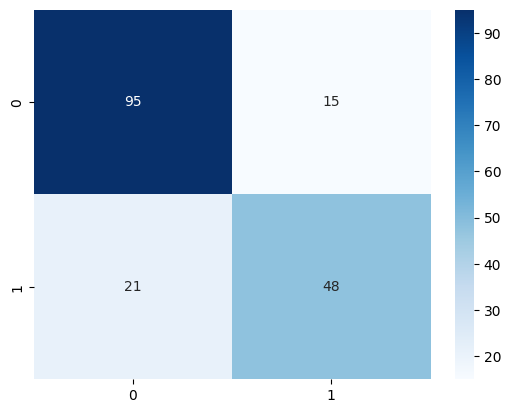

In [35]:
matrix1 = confusion_matrix(y_test,y_pred)
print(matrix1)
ax1 = sns.heatmap(matrix1, annot=True, cmap='Blues')
print(classification_report(y_test,y_pred))